In [1]:
import pyreadr
import pandas as pd
import re
from openpyxl import load_workbook
import numpy as np
import cell2location
import matplotlib.pyplot as plt
import os
import subprocess
import sys
import scanpy as sc
from scipy.io import mmread
from scipy.sparse import csr_matrix

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_file = f"../intermediate_data/cell2location_res/ovarian_cancer_signatures/ovarian_cancer_cell2location_model.h5ad"
adata_ref = sc.read_h5ad(adata_file)
mod = cell2location.models.RegressionModel.load(f"../intermediate_data/cell2location_res/ovarian_cancer_signatures", adata_ref)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


INFO     File ../intermediate_data/cell2location_res/ovarian_cancer_signatures/model.pt already downloaded         


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 1/605:   0%|                                                       | 1/605 [00:06<1:09:59,  6.95s/it, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/605:   0%|                                                       | 1/605 [00:07<1:11:45,  7.13s/it, v_num=1]


In [3]:
adata_ref.var["ensembl_id"] = adata_ref.var_names  # save old index first
adata_ref.var["symbol"] = adata_ref.var["feature_name"]
adata_ref.var = adata_ref.var.set_index("symbol")
adata_ref.var.index = adata_ref.var.index.astype(str)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [4]:
base_dir = "../intermediate_data/Human_ovarian_cancer/"

# Load spatial coordinates (same for all three)
coords = pd.read_csv(f"{base_dir}wta_spatial_coords.csv", index_col=0)


In [5]:
# Function reading the data and converting to adata
def load_spe(counts_file, genes_file, barcodes_file, coords):
    """Load a SpatialExperiment-like object as AnnData"""
    # Read sparse matrix
    counts = csr_matrix(mmread(f"{base_dir}{counts_file}")).T  # spots x genes
    genes  = pd.Index(open(f"{base_dir}{genes_file}").read().splitlines())
    spots  = pd.Index(open(f"{base_dir}{barcodes_file}").read().splitlines())

    # Build AnnData
    adata = sc.AnnData(
        X   = counts,
        obs = pd.DataFrame({"sample": "Human_Ovarian_Cancer"},index=spots),
        var = pd.DataFrame(index=genes)
    )

    # Add spatial coordinates
    adata.obsm["spatial"] = coords.loc[spots].values
    adata.obs["x_coord"]  = coords.loc[spots].iloc[:, 0].values
    adata.obs["y_coord"]  = coords.loc[spots].iloc[:, 1].values

    return adata


In [6]:
# Loading the objects
spe_wta = load_spe(
    "wta_counts.mtx",
    "wta_genes.txt",
    "wta_barcodes.txt",
    coords
)

spe_targeted_pan_cancer = load_spe(
    "targeted_pan_cancer_counts.mtx",
    "targeted_pan_cancer_genes.txt",
    "targeted_pan_cancer_barcodes.txt",
    coords
)

spe_targeted_immunology = load_spe(
    "targeted_immunology_counts.mtx",
    "targeted_immunology_genes.txt",
    "targeted_immunology_barcodes.txt",
    coords
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
def run_cell2location(
    adata_vis,
    adata_ref,
    parameter,
    ref_run,
    N_cells_per_location=20,
    detection_alpha=20,
    max_epochs=10000,
    num_samples=1000,
):
    """
    Run Cell2location deconvolution on a spatial AnnData object.

    Parameters
    ----------
    adata_vis : AnnData
        Spatial transcriptomics AnnData (e.g. Visium).
    adata_ref : AnnData
        Reference AnnData with Cell2location NB regression output in varm/var.
    parameter : str
        Label for this run (used in output filenames and directory naming).
    ref_run : str
        Base output directory path.
    N_cells_per_location : int
        Expected average cell abundance hyper-prior.
    detection_alpha : int
        Hyperparameter controlling normalisation of within-experiment RNA detection.
    max_epochs : int
        Maximum training epochs.
    num_samples : int
        Number of posterior samples to draw during export.

    Returns
    -------
    adata_vis : AnnData
        Spatial AnnData with posterior added to obsm.
    mod : Cell2location model
        Trained model object.
    res : pd.DataFrame
        Cell-type proportion table (cell_type x spots).
    """
    adata_vis = adata_vis.copy()
    adata_vis.uns.pop("_scvi_manager_uuid", None)
    adata_vis.uns.pop("_scvi_uuid", None)
    
    # --- Extract estimated expression per cluster ---
    factor_names = adata_ref.uns['mod']['factor_names']
    cols = [f'means_per_cluster_mu_fg_{i}' for i in factor_names]

    if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
        inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][cols].copy()
    else:
        inf_aver = adata_ref.var[cols].copy()

    inf_aver.columns = factor_names

    # --- Subset to shared genes ---
    #adata_vis.var_names_make_unique()
    intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
    adata_vis = adata_vis[:, intersect].copy()
    inf_aver = inf_aver.loc[intersect, :].copy()

    # --- Set up and train Cell2location ---
    cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

    mod = cell2location.models.Cell2location(
        adata_vis,
        cell_state_df=inf_aver,
        N_cells_per_location=N_cells_per_location,
        detection_alpha=detection_alpha,
    )
    mod.view_anndata_setup()

    mod.train(
        max_epochs=max_epochs,
        batch_size=None,
        train_size=1,
    )

    mod.plot_history(1000)
    plt.legend(labels=['full data training'])

    # --- Export posterior ---
    adata_vis = mod.export_posterior(
        adata_vis,
        sample_kwargs={'num_samples': num_samples, 'batch_size': mod.adata.n_obs},
    )

    # --- Save model and AnnData ---
    output_dir = f"{ref_run}/cell2location_map/{parameter}"
    os.makedirs(output_dir, exist_ok=True)
    mod.save(output_dir, overwrite=True)
    adata_vis.write(f"{output_dir}/{parameter}.h5ad")

    # --- Compute and save proportions ---
    means = adata_vis.obsm['means_cell_abundance_w_sf']
    props = means.div(means.sum(axis=1), axis=0)
    adata_vis.obsm['props_cell_abundance'] = props

    res = props.T
    res.index = (
        res.index
        .str.replace("meanscell_abundance_w_sf_", "", regex=False)
        .str.rstrip("s")
    )
    res = res.reset_index().rename(columns={"index": "cell_type"})
    res["parameter"] = parameter
    res.to_csv(f"{ref_run}/cell2location_map/{parameter}_res.csv", index=True)

    return res

In [ ]:
adata_ref = adata_ref[:, ~adata_ref.var_names.duplicated()].copy()

spe_wta_test = spe_wta[:, ~spe_wta.var_names.duplicated()].copy()
spe_wta_test.uns.pop("_scvi_manager_uuid", None)
spe_wta_test.uns.pop("_scvi_uuid", None)

human_ovarian_cancer_wta_deconv = run_cell2location(
    adata_vis=spe_wta_test,
    adata_ref=adata_ref,
    parameter="ovarian_cancer_wta",
    ref_run="../intermediate_data/cell2location_res/cell2location_map",
    N_cells_per_location=10,
    detection_alpha=20,
    max_epochs=10000,
    num_samples=500,
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.3.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 3493  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 22647 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                        batch State Registry                        
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃      Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ Human_Ovarian_Cancer │          0          │
└─────────────────────┴──────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 5/10000:   0%|                              | 4/10000 [00:20<14:01:35,  5.05s/it, v_num=1, elbo_train=5.85e+7]

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.3.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 3493  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 1229  │
└──────────────────────────┴───────┘

...

Epoch 10000/10000: 100%|█████████████████████████| 10000/10000 [51:22<00:00,  3.39it/s, v_num=1, elbo_train=2.85e+6]

`Trainer.fit` stopped: `max_epochs=10000` reached.


Epoch 10000/10000: 100%|█████████████████████████| 10000/10000 [51:22<00:00,  3.24it/s, v_num=1, elbo_train=2.85e+6]

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...



Sampling global variables, sample: 100%|██████████████████████████████████████████| 499/499 [00:15<00:00, 31.40it/s]


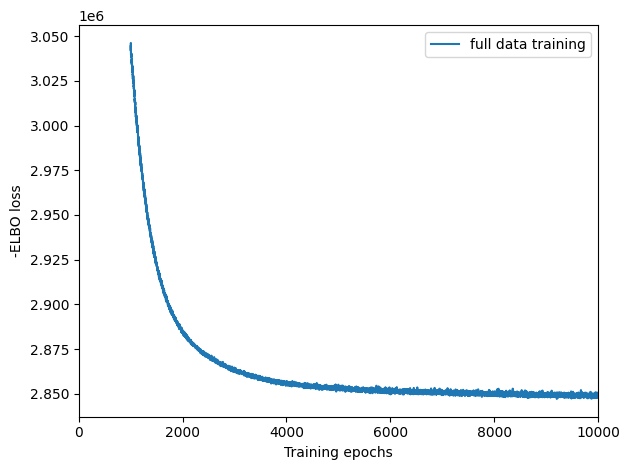

In [21]:
human_ovarian_cancer_targeted_pan_cancer = run_cell2location(
    adata_vis=spe_targeted_pan_cancer,
    adata_ref=adata_ref,
    parameter="ovarian_targeted_pan_cancer",
    ref_run="../intermediate_data/cell2location_res/cell2location_map",
    N_cells_per_location=10,
    detection_alpha=20,
    max_epochs=10000,
    num_samples=500,
)

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Anndata setup with scvi-tools version 1.3.3.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 3493  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 1034  │
└──────────────────────────┴───────┘

...

Epoch 10000/10000: 100%|█████████████████████████| 10000/10000 [43:17<00:00,  3.77it/s, v_num=1, elbo_train=2.03e+6]

`Trainer.fit` stopped: `max_epochs=10000` reached.


Epoch 10000/10000: 100%|█████████████████████████| 10000/10000 [43:17<00:00,  3.85it/s, v_num=1, elbo_train=2.03e+6]

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...



Sampling global variables, sample: 100%|██████████████████████████████████████████| 499/499 [00:14<00:00, 35.16it/s]


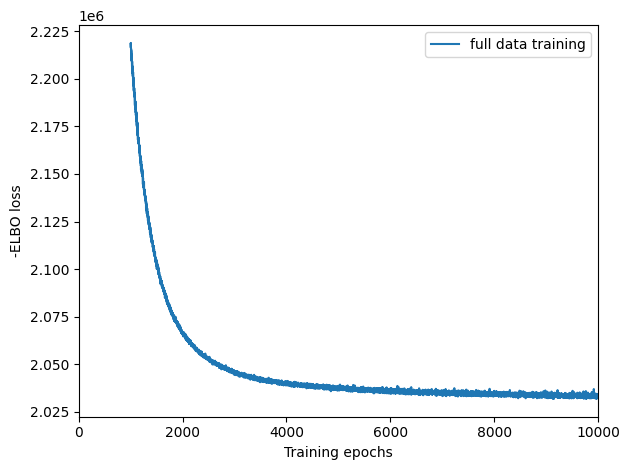

In [22]:
human_ovarian_cancer_targeted_pan_cancer = run_cell2location(
    adata_vis=spe_targeted_immunology,
    adata_ref=adata_ref,
    parameter="ovarian_targeted_immunology",
    ref_run="../intermediate_data/cell2location_res/cell2location_map",
    N_cells_per_location=10,
    detection_alpha=20,
    max_epochs=10000,
    num_samples=500,
)